In [1]:
from utils.coin_env import coin_game
import pandas as pd
import random
import time
import os
import psutil
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def rule_based_AI(state):
    """Agen Heuristik berbasis Teori Permainan Nim menggunakan parameter state."""
    if state % 4 != 1:
        move = (state - 1) % 4  # Ambil koin menuju posisi aman (kelipatan 4n + 1)
    else:
        move = random.choice([1, 2, 3])  # Langkah acak jika terjebak di posisi kalah
        
    return move

=== Tabel Q-Learning (Coin Game) ===
            Ambil 1  Ambil 2  Ambil 3
Sisa Koin                           
0           0.0000   0.0000   0.0000
1           0.0000   0.0000   0.0000
2           1.0000  -1.0000  -1.0000
3          -1.0000   1.0000  -1.0000
4          -1.0000  -1.0000   1.0000
5          -1.0000  -1.0000  -1.0000
6           0.9397  -1.0000  -1.0000
7          -0.4143   0.9408  -1.0000
8          -0.3810  -0.3456   0.9405
9          -0.9500  -0.9500  -0.9500
10          0.8714  -0.4606  -0.5693
11         -0.3775   0.8718  -0.5333
12         -0.4485  -0.4319   0.8684
13         -0.9025  -0.9025  -0.9025
14          0.7941  -0.5334  -0.5034
15         -0.5226   0.7999  -0.5113
16         -0.4996  -0.4884   0.8019
17         -0.8574  -0.8574  -0.8574
18          0.7317  -0.6086  -0.5684
19         -0.5614   0.7333  -0.5448
20         -0.5590  -0.5679   0.7347
21         -0.8145  -0.8145  -0.8145
22          0.6808  -0.6755  -0.6790
23         -0.6167   0.6783  -0.6698


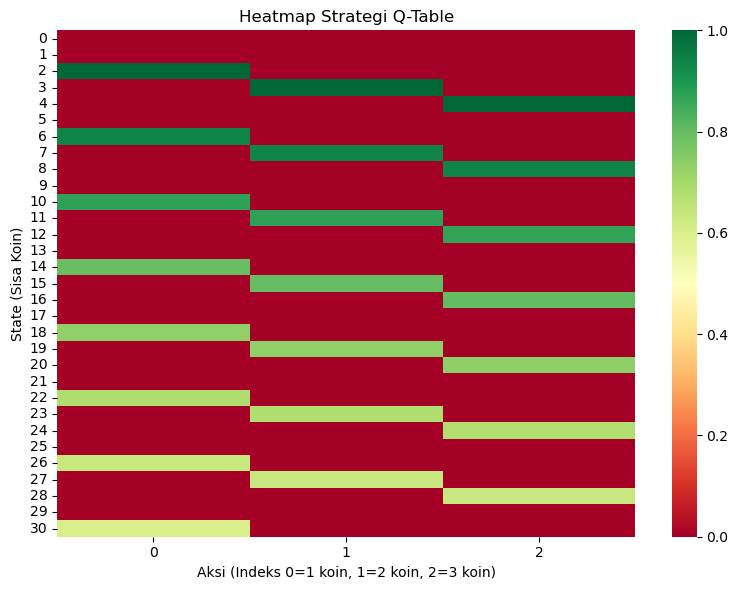

In [3]:
process = psutil.Process(os.getpid())
def get_ram_mb(): return process.memory_info().rss / 1024 / 1024

# Variabel pencatatan
start_time = time.time()
ram_peak = get_ram_mb()
convergence_episode = None

os.makedirs("utils", exist_ok=True)
Q = np.zeros((31, 3))  # Inisialisasi Q-Table: 31 State x 3 Aksi (Ambil 1, 2, 3 koin)

# --- HYPERPARAMETERS & CONFIGURATION ---
lr, gamma = 0.01, 0.95        # Learning rate (alpha) dan Discount factor
min_exp, max_exp = 0.1, 0.9    # Batas nilai eksplorasi epsilon-greedy
max_steps, max_episode = 50, 10000

# --- Q-LEARNING TRAINING LOOP ---
env = coin_game()
for episode in range(max_episode):
    state = env.reset()
    cutoff = min_exp + (max_exp - min_exp) * episode / max_episode
    
    for _ in range(max_steps):
        # Strategi Epsilon-Greedy (Eksploitasi vs Eksplorasi)
        if np.random.uniform(0, 1, 1) > cutoff:
            action = np.argmax(Q[state, :])  # Eksploitasi: Aksi terbaik di Q-Table
        else:
            action = random.choice(range(3)) # Eksplorasi: Aksi acak (0, 1, atau 2)
            
        new_state, reward, done, _ = env.step(action + 1)  # Konversi ke aksi 1, 2, 3 koin
        
        if done:
            Q[state, action] = reward; break  # Terminasi segera setelah agen melangkah
            
        # Giliran Lawan (Rule-Based AI)
        AIaction = rule_based_AI(new_state)
        new_state, reward, done, _ = env.step(AIaction)
        
        if done:
            Q[state, action] = reward; break  # Terminasi setelah lawan melangkah
        else:
            # Pembaruan Nilai Q-Table Menggunakan Persamaan Bellman (TD-Learning)
            Q[state, action] = lr * (reward + gamma * np.max(Q[new_state, :])) + (1 - lr) * Q[state, action]
            state = new_state

# Pembulatan dan Penyimpanan Q-Table
Q = np.round(Q, 4)
np.savetxt("utils/coin_Qs.csv", Q, delimiter=',')

# --- TABULASI & VISUALISASI HASIL PELATIHAN ---
df_q = pd.DataFrame(Q, columns=['Ambil 1', 'Ambil 2', 'Ambil 3'])
df_q.index.name = 'Sisa Koin'
print("=== Tabel Q-Learning (Coin Game) ===\n", df_q)

# Pembuatan Heatmap Strategi Q-Table
plt.figure(figsize=(8, 6))
sns.heatmap(Q, annot=False, cmap='RdYlGn', cbar=True, vmin=0, vmax=1)
plt.title('Heatmap Strategi Q-Table')
plt.xlabel('Aksi (Indeks 0=1 koin, 1=2 koin, 2=3 koin)'); plt.ylabel('State (Sisa Koin)')

plt.tight_layout()
plt.savefig("utils/heatmap_q_table.png")
plt.show()

# --- EKSPOR METRIK EFISIENSI ---
end_time = time.time()
current_ram = get_ram_mb()
if current_ram > ram_peak:
    ram_peak = current_ram

In [4]:
print(f"=== METRIK EFISIENSI: Q-Learning ===")
print(f"Waktu Pelatihan   : {end_time - start_time:.2f} detik")
print(f"Episode Konvergen : {'10.000 (full)'}")
print(f"Puncak RAM        : {ram_peak:.2f} MB")

=== METRIK EFISIENSI: Q-Learning ===
Waktu Pelatihan   : 5.33 detik
Episode Konvergen : 10.000 (full)
Puncak RAM        : 207.43 MB
